# Mushroom Classifier
This model's goal is to classify images of mushrooms and determine whether they are poisonous or safe.  
The model was trained with an AMD GPU, which caused a fair amount of issues and forced some architecture changes.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
import tensorflow as tf

# Verification block
print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# This will list your DirectML adapters (GPU:0 and GPU:1)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Detected: {gpus}")

C:\Users\Omistaja\anaconda3\envs\tf_directml\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Keras version: 2.10.0
TensorFlow version: 2.10.0
GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Performing data augmentation while the Jupyter server was running always crashed the kernel during training phase.  
To fix this, the entire dataset is augmented at once and saved as a new dataset.  
This means that the images are already augmented when loaded as a dataset.

In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 128
img_size = (224, 224)

# Load images
dataset = keras.utils.image_dataset_from_directory(
    '../datasets/mushroom_augmented',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    labels='inferred',
    label_mode='categorical',
    shuffle=True,
    seed=123)

num_classes = len(dataset.class_names)

Found 17461 files belonging to 9 classes.


The total dataset is now much larger than the original, because of the preprocessed images.

In [4]:
# Split dataset into validation and training
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)

In [5]:
# Prefetch datasets to improve performance
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
from keras import Sequential
from keras import layers
from keras.optimizers import Adam

Because of how older versions of tensorflow work, data augmentation MUST be done outside of the training.  
CPU bottleneck kills performance, making training take ~20x longer.

In [7]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    # Convolution
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Output
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       7

In [8]:
model.compile(optimizer=Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
from keras.callbacks import EarlyStopping

history = model.fit(
    train_dataset,
    batch_size=batch_size_n,
    epochs=64,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/64
95/95 [==============================] - 13s 127ms/step - loss: 2.1093 - accuracy: 0.2024 - val_loss: 2.0656 - val_accuracy: 0.2184
Epoch 2/64
95/95 [==============================] - 4s 45ms/step - loss: 2.0745 - accuracy: 0.2107 - val_loss: 2.0522 - val_accuracy: 0.2184
Epoch 3/64
95/95 [==============================] - 4s 45ms/step - loss: 2.0591 - accuracy: 0.2087 - val_loss: 2.0276 - val_accuracy: 0.2184
Epoch 4/64
95/95 [==============================] - 4s 45ms/step - loss: 2.0273 - accuracy: 0.2129 - val_loss: 1.9932 - val_accuracy: 0.2379
Epoch 5/64
95/95 [==============================] - 4s 45ms/step - loss: 2.0071 - accuracy: 0.2146 - val_loss: 1.9769 - val_accuracy: 0.2434
Epoch 6/64
95/95 [==============================] - 4s 45ms/step - loss: 1.9893 - accuracy: 0.2250 - val_loss: 1.9578 - val_accuracy: 0.2453
Epoch 7/64
95/95 [==============================] - 4s 45ms/step - loss: 1.9718 - accuracy: 0.2309 - val_loss: 1.9446 - val_accuracy: 0.2582
Epoch 8/64


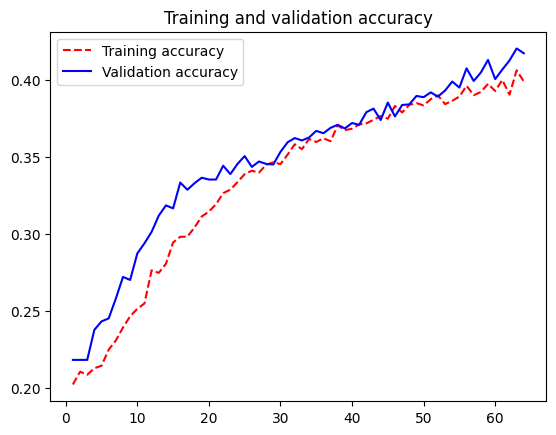

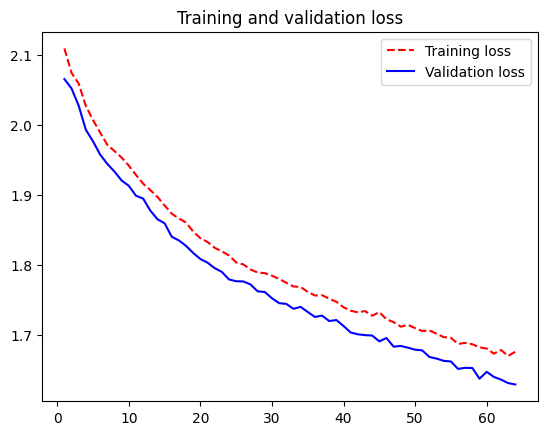

In [10]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [11]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.4304998219013214
